# 🎮 PUBG Winner Prediction Using Machine Learning

### Project Description
This project aims to predict the winning probability (`winPlacePerc`) of players in PUBG using Machine Learning techniques. The project includes data cleaning, exploratory data analysis (EDA), feature engineering, model building, evaluation, and comparison of multiple machine learning algorithms.

### Project Workflow
1. Import Libraries
2. Load Dataset
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis
6. Feature Engineering
7. Model Building
8. Model Evaluation
9. Model Comparison
10. Save Best Model
11. Conclusion

# Business Problem

Online multiplayer games such as PUBG generate a large amount of player statistics during every match. These statistics include kills, damage dealt, walking distance, healing items used, and many other gameplay features.

The objective of this project is to build a Machine Learning model that predicts a player's final winning percentage (`winPlacePerc`) based on these gameplay statistics.

Such prediction models can help game developers understand player behavior, improve matchmaking systems, detect abnormal gameplay, and enhance the overall gaming experience.

# Project Objective

The main objectives of this project are:

- Understand the PUBG dataset.
- Perform data cleaning and preprocessing.
- Explore the data using visualizations.
- Build multiple machine learning models.
- Compare model performance.
- Select the best model based on evaluation metrics.
- Save the trained model for future predictions.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Save Model
import joblib

In [2]:
# Plot settings
plt.style.use("ggplot")

# Display all columns
pd.set_option("display.max_columns", None)

# Display values with 2 decimal places
pd.options.display.float_format = "{:.2f}".format

# Dataset Loading

In [3]:
# Load Dataset
import pandas as pd

df = pd.read_csv("../data/raw/pubg.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,longestKill,matchDuration,matchType,maxPlace,numGroups,rankPoints,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,1241,0,0,0.00,1306,squad-fpp,28,26,-1,0,0.00,0,0.00,0,0,244.80,1,1466,0.44
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,0,0,0,0.00,1777,squad-fpp,26,25,1484,0,0.00,0,11.04,0,0,1434.00,5,0,0.64
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,0,0,0,0.00,1318,duo,50,47,1491,0,0.00,0,0.00,0,0,161.80,2,0,0.78
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,0,0,0,0.00,1436,squad-fpp,31,30,1408,0,0.00,0,0.00,0,0,202.70,3,0,0.17
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,0,1,1,58.53,1424,solo-fpp,97,95,1560,0,0.00,0,0.00,0,0,49.75,2,0,0.19


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4446966 entries, 0 to 4446965
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Id               str    
 1   groupId          str    
 2   matchId          str    
 3   assists          int64  
 4   boosts           int64  
 5   damageDealt      float64
 6   DBNOs            int64  
 7   headshotKills    int64  
 8   heals            int64  
 9   killPlace        int64  
 10  killPoints       int64  
 11  kills            int64  
 12  killStreaks      int64  
 13  longestKill      float64
 14  matchDuration    int64  
 15  matchType        str    
 16  maxPlace         int64  
 17  numGroups        int64  
 18  rankPoints       int64  
 19  revives          int64  
 20  rideDistance     float64
 21  roadKills        int64  
 22  swimDistance     float64
 23  teamKills        int64  
 24  vehicleDestroys  int64  
 25  walkDistance     float64
 26  weaponsAcquired  int64  
 27  winPoints        int64 

In [6]:
df.describe()

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,longestKill,matchDuration,maxPlace,numGroups,rankPoints,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
count,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446965.00
mean,0.23,1.11,130.72,0.66,0.23,1.37,47.60,505.01,0.92,0.54,23.00,1579.51,44.50,43.01,892.01,0.16,606.12,0.00,4.51,0.02,0.01,1154.22,3.66,606.46,0.47
std,0.59,1.72,170.78,1.15,0.60,2.68,27.46,627.50,1.56,0.71,50.97,258.74,23.83,23.29,736.65,0.47,1498.34,0.07,30.50,0.17,0.09,1183.50,2.46,739.70,0.31
min,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,9.00,1.00,1.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,24.00,0.00,0.00,0.00,0.00,1367.00,28.00,27.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00,155.10,2.00,0.00,0.20
50%,0.00,0.00,84.24,0.00,0.00,0.00,47.00,0.00,0.00,0.00,0.00,1438.00,30.00,30.00,1443.00,0.00,0.00,0.00,0.00,0.00,0.00,685.60,3.00,0.00,0.46
75%,0.00,2.00,186.00,1.00,0.00,2.00,71.00,1172.00,1.00,1.00,21.32,1851.00,49.00,47.00,1500.00,0.00,0.19,0.00,0.00,0.00,0.00,1976.00,5.00,1495.00,0.74
max,22.00,33.00,6616.00,53.00,64.00,80.00,101.00,2170.00,72.00,20.00,1094.00,2237.00,100.00,100.00,5910.00,39.00,40710.00,18.00,3823.00,12.00,5.00,25780.00,236.00,2013.00,1.00


# Dataset Inspection

In this section, we examine the structure and quality of the dataset before performing data cleaning. This includes checking the dataset dimensions, column names, missing values, duplicate records, and basic statistics.

In [7]:
print(f"Number of Rows : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows : 4446966
Number of Columns : 29


In [8]:
df.columns.tolist()

['Id',
 'groupId',
 'matchId',
 'assists',
 'boosts',
 'damageDealt',
 'DBNOs',
 'headshotKills',
 'heals',
 'killPlace',
 'killPoints',
 'kills',
 'killStreaks',
 'longestKill',
 'matchDuration',
 'matchType',
 'maxPlace',
 'numGroups',
 'rankPoints',
 'revives',
 'rideDistance',
 'roadKills',
 'swimDistance',
 'teamKills',
 'vehicleDestroys',
 'walkDistance',
 'weaponsAcquired',
 'winPoints',
 'winPlacePerc']

In [9]:
missing_values = df.isnull().sum()

missing_values

Id                 0
groupId            0
matchId            0
assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPoints          0
winPlacePerc       1
dtype: int64

In [10]:
missing_values[missing_values > 0]

winPlacePerc    1
dtype: int64

In [11]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False)

winPlacePerc      0.00
groupId           0.00
matchId           0.00
assists           0.00
Id                0.00
damageDealt       0.00
DBNOs             0.00
headshotKills     0.00
heals             0.00
killPlace         0.00
killPoints        0.00
kills             0.00
boosts            0.00
killStreaks       0.00
longestKill       0.00
matchType         0.00
matchDuration     0.00
numGroups         0.00
rankPoints        0.00
revives           0.00
maxPlace          0.00
rideDistance      0.00
roadKills         0.00
teamKills         0.00
swimDistance      0.00
vehicleDestroys   0.00
walkDistance      0.00
weaponsAcquired   0.00
winPoints         0.00
dtype: float64

In [12]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [13]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical Columns :", len(numerical_columns))
print("Categorical Columns :", len(categorical_columns))

Numerical Columns : 25
Categorical Columns : 4


In [14]:
data_quality = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df)) * 100,
    "Unique Values": df.nunique()
})

data_quality

,Data Type,Missing Values,Missing %,Unique Values
Id,str,0,0.00,4446966
groupId,str,0,0.00,2026745
matchId,str,0,0.00,47965
assists,int64,0,0.00,20
boosts,int64,0,0.00,27
damageDealt,float64,0,0.00,29916
DBNOs,int64,0,0.00,39
headshotKills,int64,0,0.00,34
heals,int64,0,0.00,63
killPlace,int64,0,0.00,101


# Data Cleaning

In this step, we clean the dataset by handling missing values, removing unnecessary columns, checking invalid records, and preparing the data for feature engineering and machine learning.

In [15]:
df.isnull().sum()

Id                 0
groupId            0
matchId            0
assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPoints          0
winPlacePerc       1
dtype: int64

In [16]:
df[df.isnull().any(axis=1)]

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,longestKill,matchDuration,matchType,maxPlace,numGroups,rankPoints,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
2744604,f70c74418bb064,12dfbede33f92b,224a123c53e008,0,0,0.00,0,0,0,1,0,0,0,0.00,9,solo-fpp,1,1,1574,0,0.00,0,0.00,0,0,0.00,0,0,NaN


In [17]:
df = df.dropna()

In [18]:
df.isnull().sum().sum()

np.int64(0)

In [20]:
print(df.shape)

(4446965, 29)


In [21]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [22]:
df["matchType"].value_counts()

matchType
squad-fpp           1756186
duo-fpp              996691
squad                626526
solo-fpp             536761
duo                  313591
solo                 181943
normal-squad-fpp      17174
crashfpp               6287
normal-duo-fpp         5489
flaretpp               2505
normal-solo-fpp        1682
flarefpp                718
normal-squad            516
crashtpp                371
normal-solo             326
normal-duo              199
Name: count, dtype: int64

In [23]:
df["winPlacePerc"].describe()

count   4446965.00
mean          0.47
std           0.31
min           0.00
25%           0.20
50%           0.46
75%           0.74
max           1.00
Name: winPlacePerc, dtype: float64

In [24]:
print("Minimum :", df["winPlacePerc"].min())
print("Maximum :", df["winPlacePerc"].max())

Minimum : 0.0
Maximum : 1.0


In [25]:
df.to_csv("../data/processed/pubg_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to understand the dataset through statistics and visualizations. It helps identify trends, distributions, relationships between variables, and possible outliers before building machine learning models.

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

%matplotlib inline

In [29]:
df = pd.read_csv("../data/processed/pubg_cleaned.csv")

In [30]:
print(df.shape)

(4446965, 29)


## Distribution of Target Variable (winPlacePerc)

This graph shows how the target variable is distributed.

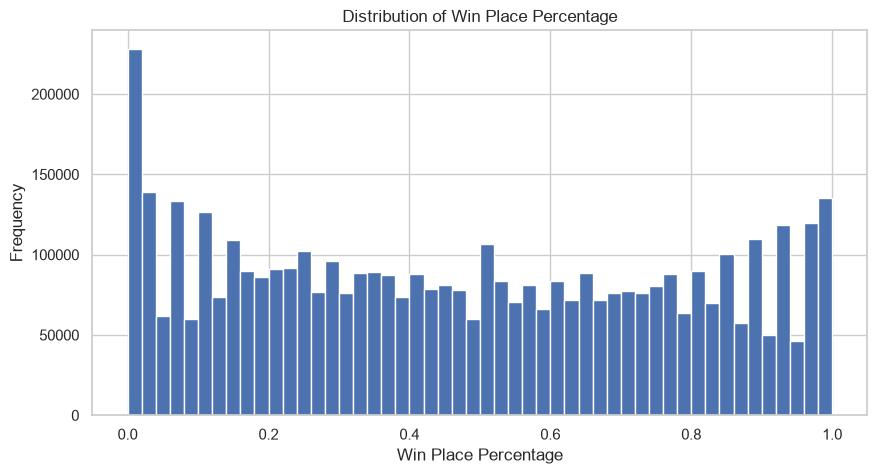

In [31]:
plt.figure(figsize=(10,5))

plt.hist(df["winPlacePerc"], bins=50)

plt.title("Distribution of Win Place Percentage")

plt.xlabel("Win Place Percentage")

plt.ylabel("Frequency")

plt.show()

## Match Type Distribution

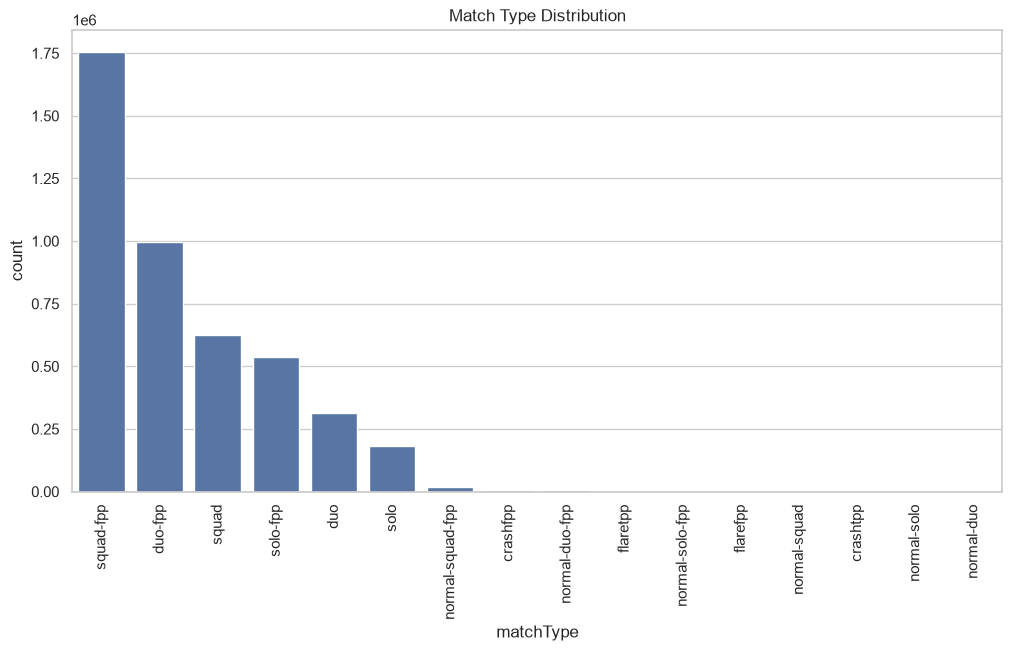

In [32]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="matchType",
    order=df["matchType"].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Match Type Distribution")

plt.show()

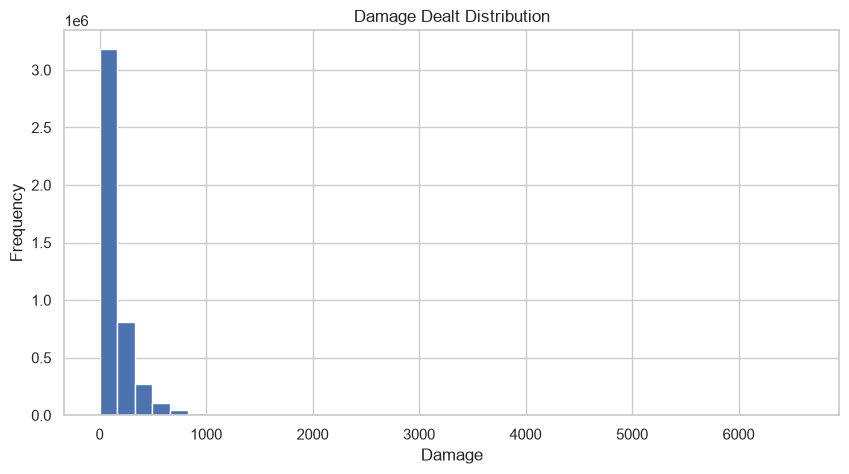

In [33]:
plt.figure(figsize=(10,5))

plt.hist(df["damageDealt"], bins=40)

plt.title("Damage Dealt Distribution")

plt.xlabel("Damage")

plt.ylabel("Frequency")

plt.show()

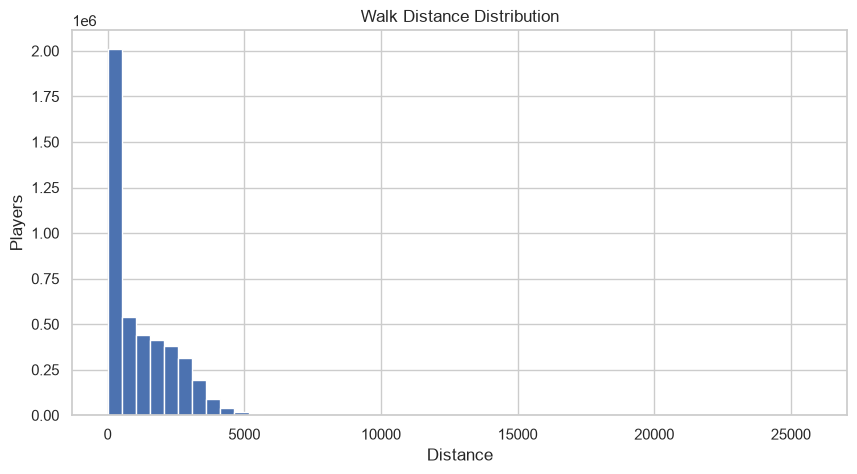

In [34]:
plt.figure(figsize=(10,5))

plt.hist(df["walkDistance"], bins=50)

plt.title("Walk Distance Distribution")

plt.xlabel("Distance")

plt.ylabel("Players")

plt.show()

In [35]:
correlation = df.corr(numeric_only=True)

target_corr = correlation["winPlacePerc"].sort_values(ascending=False)

target_corr

winPlacePerc       1.00
walkDistance       0.81
boosts             0.63
weaponsAcquired    0.58
damageDealt        0.44
heals              0.43
kills              0.42
longestKill        0.41
killStreaks        0.38
rideDistance       0.34
assists            0.30
DBNOs              0.28
headshotKills      0.28
revives            0.24
swimDistance       0.15
vehicleDestroys    0.07
numGroups          0.04
maxPlace           0.04
roadKills          0.03
teamKills          0.02
rankPoints         0.01
killPoints         0.01
winPoints          0.01
matchDuration     -0.01
killPlace         -0.72
Name: winPlacePerc, dtype: float64

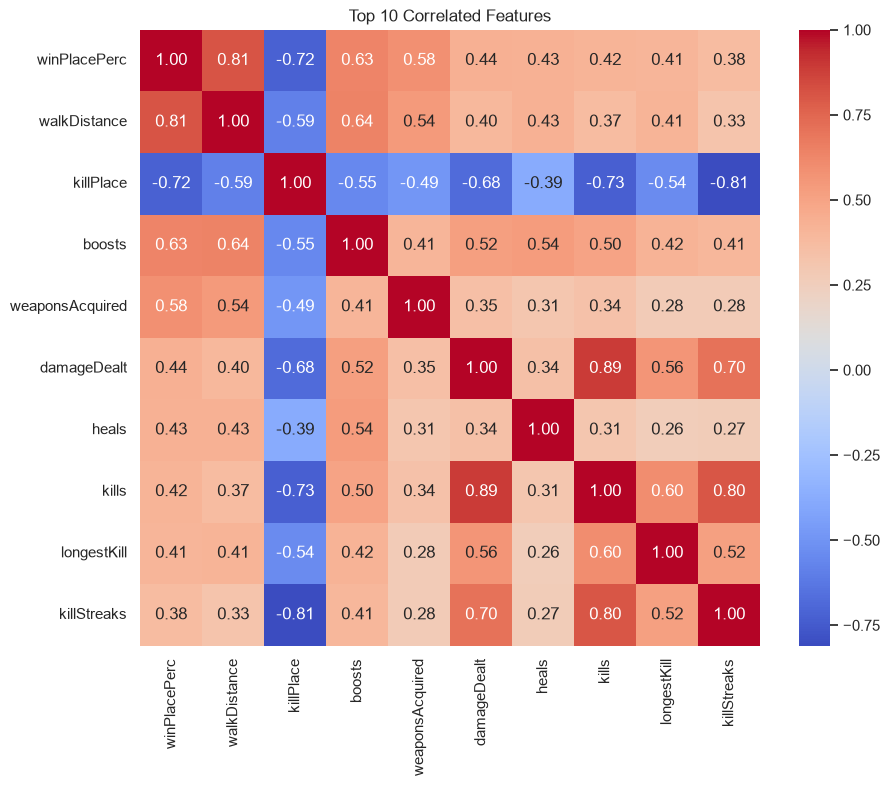

In [36]:
top_features = target_corr.abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10,8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Top 10 Correlated Features")

plt.show()

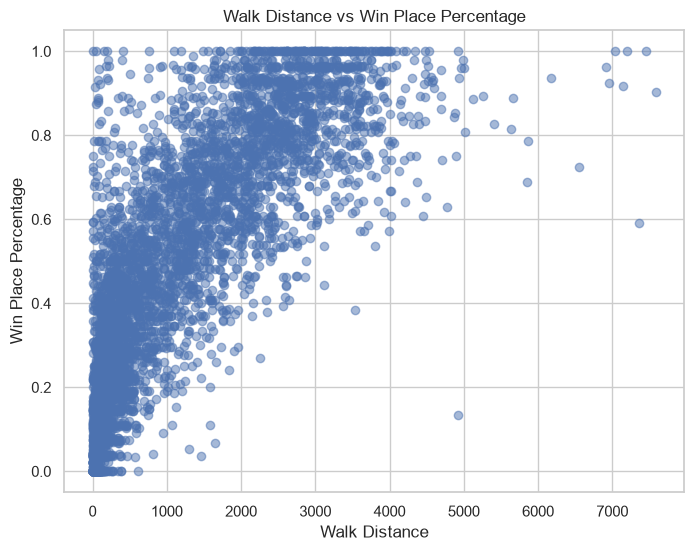

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["walkDistance"].sample(5000, random_state=42),
    df["winPlacePerc"].sample(5000, random_state=42),
    alpha=0.5
)

plt.xlabel("Walk Distance")

plt.ylabel("Win Place Percentage")

plt.title("Walk Distance vs Win Place Percentage")

plt.show()

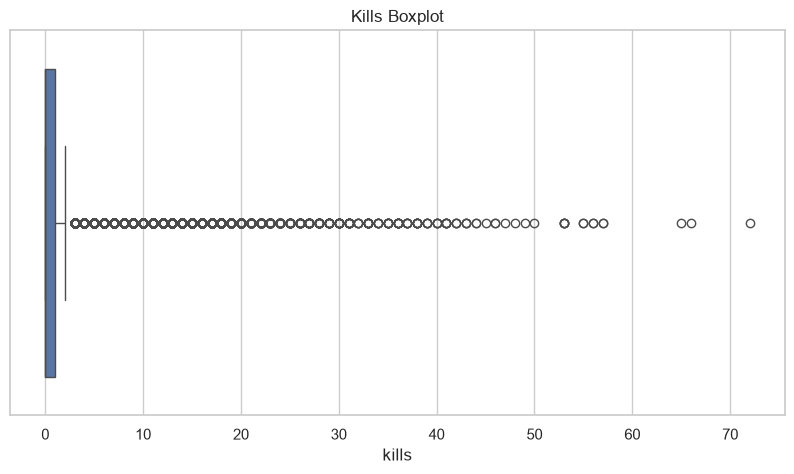

In [38]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["kills"])

plt.title("Kills Boxplot")

plt.show()

# Feature Engineering

Feature engineering is the process of preparing the dataset for machine learning by removing unnecessary columns, converting categorical variables into numerical values, creating new features if required, and separating the input features from the target variable.

In [39]:
df.columns

Index(['Id', 'groupId', 'matchId', 'assists', 'boosts', 'damageDealt', 'DBNOs',
       'headshotKills', 'heals', 'killPlace', 'killPoints', 'kills',
       'killStreaks', 'longestKill', 'matchDuration', 'matchType', 'maxPlace',
       'numGroups', 'rankPoints', 'revives', 'rideDistance', 'roadKills',
       'swimDistance', 'teamKills', 'vehicleDestroys', 'walkDistance',
       'weaponsAcquired', 'winPoints', 'winPlacePerc'],
      dtype='str')

In [40]:
df.drop(columns=["Id", "groupId", "matchId"], inplace=True)

In [41]:
df.columns

Index(['assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills', 'heals',
       'killPlace', 'killPoints', 'kills', 'killStreaks', 'longestKill',
       'matchDuration', 'matchType', 'maxPlace', 'numGroups', 'rankPoints',
       'revives', 'rideDistance', 'roadKills', 'swimDistance', 'teamKills',
       'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winPoints',
       'winPlacePerc'],
      dtype='str')

In [42]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["matchType"] = encoder.fit_transform(df["matchType"])

In [43]:
df["matchType"].head()

0    15
1    15
2     2
3    15
4    13
Name: matchType, dtype: int64

In [44]:
df.dtypes

assists              int64
boosts               int64
damageDealt        float64
DBNOs                int64
headshotKills        int64
heals                int64
killPlace            int64
killPoints           int64
kills                int64
killStreaks          int64
longestKill        float64
matchDuration        int64
matchType            int64
maxPlace             int64
numGroups            int64
rankPoints           int64
revives              int64
rideDistance       float64
roadKills            int64
swimDistance       float64
teamKills            int64
vehicleDestroys      int64
walkDistance       float64
weaponsAcquired      int64
winPoints            int64
winPlacePerc       float64
dtype: object

In [59]:
# ==========================================
# Take a Sample for Model Training
# ==========================================

df_sample = df.sample(n=200000, random_state=42)

print("Original Dataset Shape :", df.shape)
print("Sample Dataset Shape   :", df_sample.shape)

# Features and Target
X = df_sample.drop("winPlacePerc", axis=1)
y = df_sample["winPlacePerc"]

Original Dataset Shape : (4446965, 26)
Sample Dataset Shape   : (200000, 26)


In [60]:
print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (200000, 25)
Target Shape : (200000,)


In [61]:
y.head()

4270779   0.28
1687951   0.86
3732582   0.78
3386216   0.14
243580    0.73
Name: winPlacePerc, dtype: float64

In [62]:
feature_data = pd.concat([X, y], axis=1)

feature_data.to_csv("../data/processed/pubg_feature_engineered.csv", index=False)

print("Feature engineered dataset saved successfully!")

Feature engineered dataset saved successfully!


# Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the machine learning model, while the testing set is used to evaluate the model's performance on unseen data.

We use an 80:20 split, which is a standard practice in machine learning.

In [63]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [64]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (160000, 25)
Testing Features  : (40000, 25)
Training Target   : (160000,)
Testing Target    : (40000,)


# Model 1 - Linear Regression

Linear Regression is used as a baseline model. It predicts the target variable by assuming a linear relationship between the input features and the target.

In [65]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [66]:
print(X_train.select_dtypes(include=["object"]).columns)

Index([], dtype='str')


In [67]:
lr_predictions = lr_model.predict(X_test)

In [68]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, lr_predictions)
mse = mean_squared_error(y_test, lr_predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, lr_predictions)

print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))

MAE : 0.092
MSE : 0.0158
RMSE: 0.1258
R² Score: 0.8321


# Model 2 - Decision Tree Regressor

Decision Tree Regressor predicts the target value by learning decision rules from the training data. It can capture non-linear relationships between features and the target variable.

In [69]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=20
)

dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [70]:
dt_predictions = dt_model.predict(X_test)

In [72]:
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = dt_mse ** 0.5
dt_r2 = r2_score(y_test, dt_predictions)

print("MAE :", round(dt_mae,4))
print("MSE :", round(dt_mse,4))
print("RMSE:", round(dt_rmse,4))
print("R² :", round(dt_r2,4))

MAE : 0.0817
MSE : 0.0141
RMSE: 0.1186
R² : 0.8508


# Model 3 - Random Forest Regressor

Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is one of the most reliable machine learning algorithms for regression tasks.

In [73]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=30,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [74]:
rf_predictions = rf_model.predict(X_test)

In [75]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = rf_mse ** 0.5
rf_r2 = r2_score(y_test, rf_predictions)

print("MAE :", round(rf_mae,4))
print("MSE :", round(rf_mse,4))
print("RMSE:", round(rf_rmse,4))
print("R² :", round(rf_r2,4))

MAE : 0.062
MSE : 0.0077
RMSE: 0.0879
R² : 0.918


# Model 4 - XGBoost Regressor

XGBoost is an advanced gradient boosting algorithm that builds trees sequentially to improve prediction performance. It is widely used in machine learning competitions and industry applications.

In [76]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [77]:
xgb_predictions = xgb_model.predict(X_test)

In [78]:
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_rmse = xgb_mse ** 0.5
xgb_r2 = r2_score(y_test, xgb_predictions)

print("MAE :", round(xgb_mae,4))
print("MSE :", round(xgb_mse,4))
print("RMSE:", round(xgb_rmse,4))
print("R² :", round(xgb_r2,4))

MAE : 0.0586
MSE : 0.0067
RMSE: 0.082
R² : 0.9286


# Model Comparison

In this section, the performance of all machine learning models is compared using evaluation metrics. The model with the best performance will be selected for deployment.

In [79]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae,
        xgb_mae
    ],
    "MSE": [
        mse,
        dt_mse,
        rf_mse,
        xgb_mse
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        r2,
        dt_r2,
        rf_r2,
        xgb_r2
    ]
})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.09,0.02,0.13,0.83
1,Decision Tree,0.08,0.01,0.12,0.85
2,Random Forest,0.06,0.01,0.09,0.92
3,XGBoost,0.06,0.01,0.08,0.93


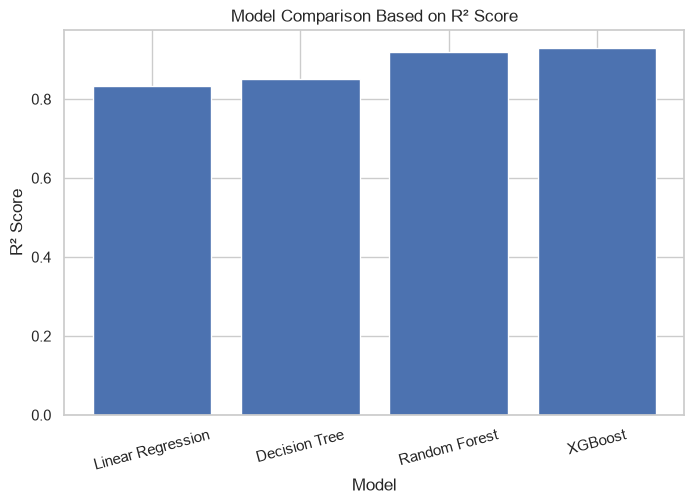

In [80]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["R2 Score"])

plt.title("Model Comparison Based on R² Score")

plt.xlabel("Model")

plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.show()

# Save the Best Model

After comparing all machine learning models, the best-performing model is saved using the Joblib library. Saving the model allows it to be loaded later without retraining, making it suitable for deployment in a web application.

In [81]:
import joblib

In [82]:
best_model_name = comparison.loc[
    comparison["R2 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [83]:
if best_model_name == "Linear Regression":
    best_model = lr_model

elif best_model_name == "Decision Tree":
    best_model = dt_model

elif best_model_name == "Random Forest":
    best_model = rf_model

else:
    best_model = xgb_model

joblib.dump(best_model, "../models/pubg_best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [84]:
loaded_model = joblib.load("../models/pubg_best_model.pkl")

print(type(loaded_model))

<class 'xgboost.sklearn.XGBRegressor'>


In [85]:
sample_prediction = loaded_model.predict(X_test.iloc[:5])

print(sample_prediction)

[0.49428478 0.22287877 0.27871898 0.6382299  0.71271825]


In [86]:
print(type(loaded_model))

<class 'xgboost.sklearn.XGBRegressor'>
